In [2]:
from google.colab import files

uploaded = files.upload()

Saving NIDS_combined.parquet to NIDS_combined.parquet


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.decomposition import PCA
df = pd.read_parquet('NIDS_combined.parquet')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Shape: (2313810, 78)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.dtypes

Number of rows: 2313810
Number of columns: 78


,0
Protocol,int8
Flow Duration,int32
Total Fwd Packets,int32
Total Backward Packets,int32
Fwd Packets Length Total,int32
...,...
Idle Mean,float32
Idle Std,float32
Idle Max,int32
Idle Min,int32


In [5]:
dtype_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values
})

display(dtype_df)

,Column,Data Type
0,Protocol,int8
1,Flow Duration,int32
2,Total Fwd Packets,int32
3,Total Backward Packets,int32
4,Fwd Packets Length Total,int32
...,...,...
73,Idle Mean,float32
74,Idle Std,float32
75,Idle Max,int32
76,Idle Min,int32


In [6]:
df.describe()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,...,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2.313810e+06,2313810.0,2.313810e+06,2.313810e+06,2.313810e+06
mean,1.050673e+01,1.807575e+07,1.108391e+01,1.255334e+01,6.664045e+02,1.976976e+04,2.506291e+02,2.142396e+01,6.880502e+01,8.299153e+01,...,6.537630e+00,-3.360480e+03,9.977085e+04,5.032398e+04,1.874053e+05,7.131980e+04,10172613.0,6.164088e+05,1.063716e+07,9.688133e+06
std,5.416040e+00,3.640823e+07,8.291879e+02,1.103179e+03,1.105009e+04,2.503141e+06,7.855073e+02,6.334192e+01,2.017213e+02,3.041364e+02,...,7.039324e+02,1.200084e+06,7.120588e+05,4.322412e+05,1.131814e+06,6.375820e+05,25991066.0,5.065188e+06,2.656441e+07,2.550670e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.000000e+00,4.760000e+02,2.000000e+00,1.000000e+00,3.700000e+01,2.600000e+01,2.000000e+01,0.000000e+00,8.666667e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.000000e+00,6.478300e+04,2.000000e+00,2.000000e+00,7.400000e+01,1.830000e+02,4.300000e+01,6.000000e+00,3.955556e+01,0.000000e+00,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.700000e+01,5.856948e+06,6.000000e+00,5.000000e+00,3.560000e+02,2.306000e+03,2.740000e+02,3.900000e+01,5.400000e+01,8.499406e+01,...,3.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00
max,1.700000e+01,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,120000000.0,7.690000e+07,1.200000e+08,1.200000e+08


In [7]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Number of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Number of numerical columns: 77
Number of categorical columns: 1

Categorical columns:
['Label']

Numerical columns:
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'R

In [8]:
unique_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Unique Values': [df[col].nunique(dropna=False) for col in df.columns]
})

display(unique_df)

,Column,Data Type,Unique Values
0,Protocol,int8,3
1,Flow Duration,int32,1050898
2,Total Fwd Packets,int32,1432
3,Total Backward Packets,int32,1747
4,Fwd Packets Length Total,int32,17928
...,...,...,...
73,Idle Mean,float32,197144
74,Idle Std,float32,196816
75,Idle Max,int32,149737
76,Idle Min,int32,223888


In [9]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Percentage of duplicate rows:",
      (duplicate_count / len(df)) * 100)

Number of duplicate rows: 82004
Percentage of duplicate rows: 3.544111227801764


In [17]:
# Check whether duplicate rows have different labels

duplicate_rows = df[df.duplicated(keep=False)]

print("Total rows involved in duplicate groups:", len(duplicate_rows))

# Check labels among duplicate rows
display(
    duplicate_rows['Label'].value_counts().to_frame('Count')
)

Total rows involved in duplicate groups: 131375


,Count
Label,
Benign,131375


In [10]:
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing Percentage': (
        df.isnull().sum().values / len(df) * 100
    )
})

missing_df = missing_df.sort_values(
    by='Missing Count',
    ascending=False
)

display(missing_df)

,Column,Missing Count,Missing Percentage
0,Protocol,0,0.0
1,Flow Duration,0,0.0
2,Total Fwd Packets,0,0.0
3,Total Backward Packets,0,0.0
4,Fwd Packets Length Total,0,0.0
...,...,...,...
73,Idle Mean,0,0.0
74,Idle Std,0,0.0
75,Idle Max,0,0.0
76,Idle Min,0,0.0


Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
Label
Benign                        85.457233
DoS Hulk                       7.470190
DDoS                           5.532606
DoS GoldenEye                  0.444548
FTP-Patator                    0.256330
DoS slowloris                  0.232733
DoS Slowhttptest               0.225948
SSH-Patator                    0.139121
PortScan                       0.084536
Web Attack � Brute Force       0

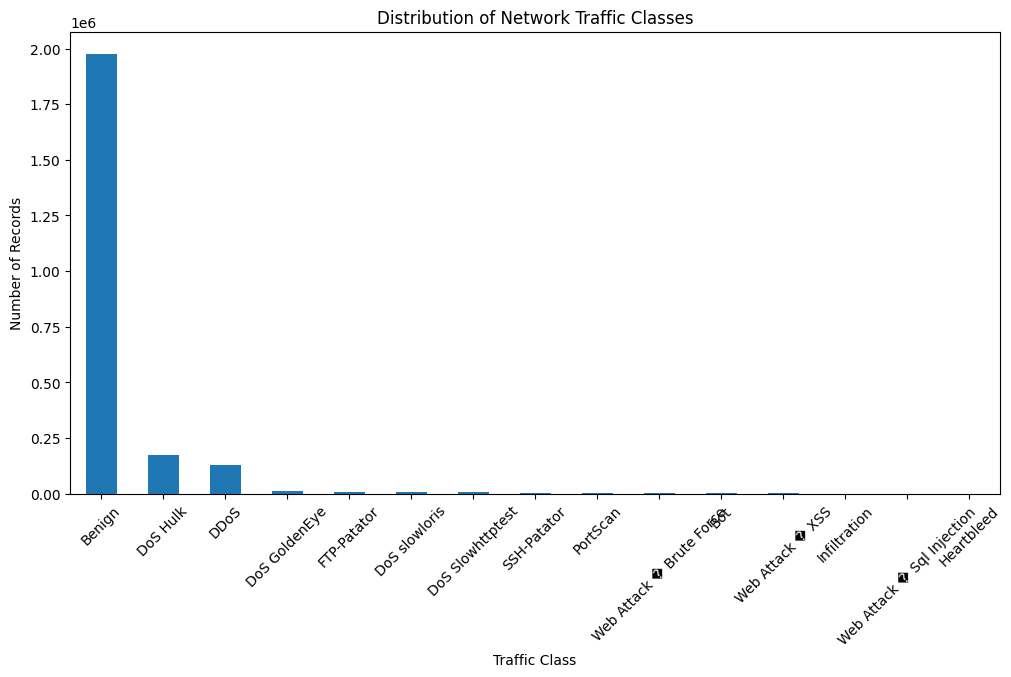

In [11]:
print(df['Label'].value_counts())
print(df['Label'].value_counts(normalize=True) * 100)
plt.figure(figsize=(12, 6))
df['Label'].value_counts().plot(kind='bar')

plt.title('Distribution of Network Traffic Classes')
plt.xlabel('Traffic Class')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.show()

In [12]:
skewness = df[numerical_cols].skew().sort_values(ascending=False)

display(skewness.to_frame('Skewness'))

,Skewness
Fwd Packets Length Total,728.994260
Subflow Fwd Bytes,727.211550
Fwd URG Flags,317.171192
CWE Flag Count,317.171192
Fwd Act Data Packets,257.301649
...,...
Fwd Avg Bulk Rate,0.000000
Bwd Avg Bytes/Bulk,0.000000
Fwd Seg Size Min,-429.023965
Bwd Header Length,-648.263419


In [13]:
print(df['Protocol'].value_counts())
print("\nUnique values:")
print(sorted(df['Protocol'].unique()))

Protocol
6     1363379
17     948842
0        1589
Name: count, dtype: int64

Unique values:
[np.int8(0), np.int8(6), np.int8(17)]


In [14]:
variance = df[numerical_cols].var() #constant features

constant_features = variance[variance == 0]

print("Number of constant features:", len(constant_features))

if len(constant_features) > 0:
    print("\nConstant features:")
    print(constant_features)
else:
    print("No constant features found.")

Number of constant features: 8

Constant features:
Bwd PSH Flags           0.0
Bwd URG Flags           0.0
Fwd Avg Bytes/Bulk      0.0
Fwd Avg Packets/Bulk    0.0
Fwd Avg Bulk Rate       0.0
Bwd Avg Bytes/Bulk      0.0
Bwd Avg Packets/Bulk    0.0
Bwd Avg Bulk Rate       0.0
dtype: float64


In [16]:
constant_features = [
    'Bwd PSH Flags',
    'Bwd URG Flags',
    'Fwd Avg Bytes/Bulk',
    'Fwd Avg Packets/Bulk',
    'Fwd Avg Bulk Rate',
    'Bwd Avg Bytes/Bulk',
    'Bwd Avg Packets/Bulk',
    'Bwd Avg Bulk Rate'
]

df = df.drop(columns=constant_features) #they were constant

print("Removed constant features:", len(constant_features))
print("New dataset shape:", df.shape)

Removed constant features: 8
New dataset shape: (2313810, 70)


In [18]:
duplicate_rows_to_remove = df.duplicated().sum()

print("Exact duplicate rows to remove:", duplicate_rows_to_remove)
print("Rows before removal:", len(df))

df_no_duplicates = df.drop_duplicates()

print("Rows after removal:", len(df_no_duplicates))
print("Rows removed:", len(df) - len(df_no_duplicates))

Exact duplicate rows to remove: 82004
Rows before removal: 2313810
Rows after removal: 2231806
Rows removed: 82004


In [19]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after duplicate removal:", df.shape)

Dataset shape after duplicate removal: (2231806, 70)


In [20]:
# Numerical columns after removing constant features
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    (df[numerical_cols] < lower_bound) |
    (df[numerical_cols] > upper_bound)
).sum()

outlier_percentage = (outlier_counts / len(df)) * 100

outlier_summary = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Outlier Percentage': outlier_percentage
}).sort_values(
    'Outlier Percentage',
    ascending=False
)

display(outlier_summary)

,Outlier Count,Outlier Percentage
Active Min,554423,24.841899
Active Mean,537660,24.090804
Active Max,537660,24.090804
Flow Packets/s,520823,23.336392
Fwd Packets/s,510332,22.866324
...,...,...
Fwd URG Flags,23,0.001031
CWE Flag Count,23,0.001031
Protocol,0,0.000000
ACK Flag Count,0,0.000000


In [21]:
# Separate features and target

X = df.drop(columns=['Label'])
y = df['Label']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:", y.nunique())
print("\nClass distribution:")
print(y.value_counts())

Features shape: (2231806, 69)
Target shape: (2231806,)

Target classes: 15

Class distribution:
Label
Benign                        1895314
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1785444, 69)
Testing features: (446362, 69)
Training target: (1785444,)
Testing target: (446362,)


In [23]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(3))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(3))

Training class distribution:
Label
Benign                        84.923
DoS Hulk                       7.745
DDoS                           5.736
DoS GoldenEye                  0.461
FTP-Patator                    0.266
DoS slowloris                  0.241
DoS Slowhttptest               0.234
SSH-Patator                    0.144
PortScan                       0.088
Web Attack � Brute Force       0.066
Bot                            0.064
Web Attack � XSS               0.029
Infiltration                   0.002
Web Attack � Sql Injection     0.001
Heartbleed                     0.001
Name: proportion, dtype: float64

Testing class distribution:
Label
Benign                        84.923
DoS Hulk                       7.745
DDoS                           5.736
DoS GoldenEye                  0.461
FTP-Patator                    0.266
DoS slowloris                  0.241
DoS Slowhttptest               0.234
SSH-Patator                    0.144
PortScan                       0.088
Web Attac

In [24]:
print("Training feature dtypes:")
display(X_train.dtypes.value_counts())

print("\nCategorical feature:")
print(X_train.select_dtypes(include=['object', 'category']).columns.tolist())

Training feature dtypes:


,count
int32,26
float32,22
int8,11
int16,7
float64,2
int64,1



Categorical feature:
[]


In [25]:
# Protocol is categorical despite being stored as an integer
categorical_cols = ['Protocol']

# All other features are numerical
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

print("Categorical features:", categorical_cols)
print("Number of numerical features:", len(numerical_cols))
print("Number of categorical features:", len(categorical_cols))

Categorical features: ['Protocol']
Number of numerical features: 68
Number of categorical features: 1


In [27]:
# Analyze skewness after train-test split

train_skewness = X_train[numerical_cols].skew()

skew_summary = pd.DataFrame({
    'Skewness': train_skewness,
    'Absolute Skewness': train_skewness.abs()
}).sort_values('Absolute Skewness', ascending=False)

display(skew_summary)

,Skewness,Absolute Skewness
Fwd Header Length,-1053.655352,1053.655352
Fwd Packets Length Total,705.537053,705.537053
Subflow Fwd Bytes,703.986504,703.986504
Bwd Header Length,-571.402978,571.402978
CWE Flag Count,385.725615,385.725615
...,...,...
Packet Length Mean,2.036551,2.036551
Fwd IAT Total,1.789221,1.789221
Flow Duration,1.769373,1.769373
ACK Flag Count,0.982464,0.982464


In [28]:
# Check negative values in numerical features

negative_counts = (X_train[numerical_cols] < 0).sum()

negative_summary = negative_counts[
    negative_counts > 0
].sort_values(ascending=False)

print("Features containing negative values:")
display(negative_summary)

Features containing negative values:


,0
Init Bwd Win Bytes,896568
Init Fwd Win Bytes,727582
Flow IAT Min,2247
Flow Duration,64
Flow Packets/s,64
Flow IAT Mean,64
Flow IAT Max,64
Flow Bytes/s,42
Fwd Seg Size Min,31
Fwd Header Length,31


In [29]:
# Check zero values

zero_counts = (X_train[numerical_cols] == 0).sum()

zero_summary = pd.DataFrame({
    'Zero Count': zero_counts,
    'Zero Percentage': (zero_counts / len(X_train)) * 100
}).sort_values('Zero Percentage', ascending=False)

display(zero_summary)

,Zero Count,Zero Percentage
CWE Flag Count,1785432,99.999328
Fwd URG Flags,1785432,99.999328
RST Flag Count,1784903,99.969699
ECE Flag Count,1784900,99.969531
FIN Flag Count,1725062,96.618096
...,...,...
Total Fwd Packets,0,0.000000
Flow IAT Mean,0,0.000000
Flow Packets/s,0,0.000000
Flow IAT Max,0,0.000000


In [30]:
# Correlation analysis on training data only

correlation_matrix = X_train[numerical_cols].corr()

# Find highly correlated feature pairs
high_corr_pairs = []

for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        corr = correlation_matrix.iloc[i, j]

        if abs(corr) >= 0.95:
            high_corr_pairs.append(
                (numerical_cols[i], numerical_cols[j], corr)
            )

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=['Feature 1', 'Feature 2', 'Correlation']
).sort_values(
    'Correlation',
    key=abs,
    ascending=False
)

print("Number of highly correlated pairs:", len(high_corr_df))
display(high_corr_df)

Number of highly correlated pairs: 38


,Feature 1,Feature 2,Correlation
3,Total Fwd Packets,Subflow Fwd Packets,1.000000
27,Fwd PSH Flags,SYN Flag Count,1.000000
28,Fwd URG Flags,CWE Flag Count,1.000000
19,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000
15,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000
8,Total Backward Packets,Subflow Bwd Packets,1.000000
13,Bwd Packets Length Total,Subflow Bwd Bytes,1.000000
10,Fwd Packets Length Total,Subflow Fwd Bytes,0.999999
32,Subflow Fwd Packets,Subflow Bwd Packets,0.999343
4,Total Fwd Packets,Subflow Bwd Packets,0.999343


In [32]:
# Find highly correlated feature pairs

corr_matrix = X_train[numerical_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column
    for column in upper.columns
    if any(upper[column] >= 0.95)
]

print("Number of candidate features for removal:", len(high_corr_features))
print("\nCandidate features:")
print(high_corr_features)

Number of candidate features for removal: 22

Candidate features:
['Total Backward Packets', 'Bwd Packets Length Total', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd Packets/s', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Idle Mean', 'Idle Max', 'Idle Min']


In [33]:
corr_matrix = X_train[numerical_cols].corr().abs()

candidate_features = [
    'Total Backward Packets',
    'Bwd Packets Length Total',
    'Fwd Packet Length Std',
    'Bwd Packet Length Mean',
    'Bwd Packet Length Std',
    'Fwd IAT Total',
    'Fwd IAT Max',
    'Fwd Packets/s',
    'Packet Length Std',
    'SYN Flag Count',
    'CWE Flag Count',
    'ECE Flag Count',
    'Avg Packet Size',
    'Avg Fwd Segment Size',
    'Avg Bwd Segment Size',
    'Subflow Fwd Packets',
    'Subflow Fwd Bytes',
    'Subflow Bwd Packets',
    'Subflow Bwd Bytes',
    'Idle Mean',
    'Idle Max',
    'Idle Min'
]

for feature in candidate_features:
    correlations = corr_matrix[feature].drop(feature)
    most_correlated = correlations.idxmax()
    highest_corr = correlations.max()

    print(f"{feature:<30} <-> {most_correlated:<30} {highest_corr:.6f}")

Total Backward Packets         <-> Subflow Bwd Packets            1.000000
Bwd Packets Length Total       <-> Subflow Bwd Bytes              1.000000
Fwd Packet Length Std          <-> Fwd Packet Length Max          0.968565
Bwd Packet Length Mean         <-> Avg Bwd Segment Size           1.000000
Bwd Packet Length Std          <-> Bwd Packet Length Max          0.982256
Fwd IAT Total                  <-> Flow Duration                  0.998504
Fwd IAT Max                    <-> Flow IAT Max                   0.998026
Fwd Packets/s                  <-> Flow Packets/s                 0.960430
Packet Length Std              <-> Packet Length Max              0.983604
SYN Flag Count                 <-> Fwd PSH Flags                  1.000000
CWE Flag Count                 <-> Fwd URG Flags                  1.000000
ECE Flag Count                 <-> RST Flag Count                 0.997238
Avg Packet Size                <-> Packet Length Mean             0.998262
Avg Fwd Segment Size     

In [34]:
features_to_remove = [
    # Packet/subflow duplicates
    'Subflow Fwd Packets',
    'Subflow Fwd Bytes',
    'Subflow Bwd Packets',
    'Subflow Bwd Bytes',

    # Duplicate/derived packet-size measures
    'Avg Fwd Segment Size',
    'Avg Bwd Segment Size',
    'Avg Packet Size',

    # Highly correlated timing/rate measures
    'Fwd IAT Total',
    'Fwd IAT Max',
    'Fwd Packets/s',

    # Highly correlated packet-length measures
    'Fwd Packet Length Std',
    'Bwd Packet Length Std',
    'Packet Length Std',

    # Highly correlated flag measures
    'SYN Flag Count',
    'CWE Flag Count',
    'ECE Flag Count'
]

X_train_selected = X_train.drop(columns=features_to_remove)
X_test_selected = X_test.drop(columns=features_to_remove)

print("Original features:", X_train.shape[1])
print("Removed features:", len(features_to_remove))
print("Remaining features:", X_train_selected.shape[1])

Original features: 69
Removed features: 16
Remaining features: 53


In [35]:
categorical_cols = ['Protocol']

numerical_cols = [
    col for col in X_train_selected.columns
    if col not in categorical_cols
]

print("Categorical features:", categorical_cols)
print("Number of numerical features:", len(numerical_cols))
print("Total features:", len(categorical_cols) + len(numerical_cols))

Categorical features: ['Protocol']
Number of numerical features: 52
Total features: 53


In [36]:
skewness = X_train_selected[numerical_cols].skew().sort_values(ascending=False)

print("Most positively skewed features:")
print(skewness.head(10))

print("\nMost negatively skewed features:")
print(skewness.tail(10))

Most positively skewed features:
Fwd Packets Length Total    705.537053
Fwd URG Flags               385.725615
Fwd Act Data Packets        261.785267
Total Fwd Packets           221.182507
Bwd Packets Length Total    220.950870
Total Backward Packets      220.756353
Flow Bytes/s                168.786759
RST Flag Count               57.421878
Active Min                   40.725893
Active Std                   36.331692
dtype: float64

Most negatively skewed features:
Bwd IAT Total                2.447642
Packet Length Max            2.413348
Bwd Packet Length Mean       2.133282
Packet Length Mean           2.036551
Flow Duration                1.769373
ACK Flag Count               0.982464
PSH Flag Count               0.969778
Fwd Seg Size Min          -381.169082
Bwd Header Length         -571.402978
Fwd Header Length        -1053.655352
dtype: float64


In [38]:
skewed_features = [
    'Fwd Packets Length Total',
    'Fwd Act Data Packets',
    'Total Fwd Packets',
    'Bwd Packets Length Total',
    'Total Backward Packets',
    'Flow Bytes/s',
    'Active Min',
    'Active Std',
    'Fwd Seg Size Min',
    'Bwd Header Length',
    'Fwd Header Length'
]
for col in skewed_features:
    print(
        f"{col:<30} "
        f"min={X_train_selected[col].min():>15.3f}   "
        f"max={X_train_selected[col].max():>15.3f}"
    )

Fwd Packets Length Total       min=          0.000   max=   12900000.000
Fwd Act Data Packets           min=          0.000   max=     213557.000
Total Fwd Packets              min=          1.000   max=     219759.000
Bwd Packets Length Total       min=          0.000   max=  655453030.000
Total Backward Packets         min=          0.000   max=     291922.000
Flow Bytes/s                   min= -261000000.000   max= 2071000000.000
Active Min                     min=          0.000   max=  107000000.000
Active Std                     min=          0.000   max=   74200000.000
Fwd Seg Size Min               min= -536870661.000   max=        138.000
Bwd Header Length              min=-1073741320.000   max=    5838440.000
Fwd Header Length              min=-32212234632.000   max=    4644908.000


In [39]:
negative_counts = (X_train_selected[numerical_cols] < 0).sum()

negative_counts = negative_counts[negative_counts > 0].sort_values(ascending=False)

print(negative_counts)

Init Bwd Win Bytes    896568
Init Fwd Win Bytes    727582
Flow IAT Min            2247
Flow Duration             64
Flow Packets/s            64
Flow IAT Mean             64
Flow IAT Max              64
Flow Bytes/s              42
Fwd Seg Size Min          31
Fwd Header Length         31
Bwd Header Length         20
Fwd IAT Min               14
dtype: int64


In [40]:
suspicious_cols = [
    'Fwd Seg Size Min',
    'Bwd Header Length',
    'Fwd Header Length',
    'Flow Bytes/s'
]

for col in suspicious_cols:
    print(f"\n{col}")
    print(X_train_selected.loc[
        X_train_selected[col] < 0, col
    ].describe())


Fwd Seg Size Min
count    3.100000e+01
mean    -2.419161e+08
std      2.228605e+08
min     -5.368707e+08
25%     -5.368707e+08
50%     -8.388531e+07
75%     -8.388531e+07
max     -1.000000e+00
Name: Fwd Seg Size Min, dtype: float64

Bwd Header Length
count    2.000000e+01
mean    -3.481262e+08
std      4.310792e+08
min     -1.073741e+09
25%     -3.942631e+08
50%     -8.388520e+07
75%     -8.388512e+07
max     -8.388501e+07
Name: Bwd Header Length, dtype: float64

Fwd Header Length
count    3.100000e+01
mean    -2.351513e+09
std      6.006045e+09
min     -3.221223e+10
25%     -1.073741e+09
50%     -1.677705e+08
75%     -8.388514e+07
max     -1.100000e+01
Name: Fwd Header Length, dtype: float64

Flow Bytes/s
count    4.200000e+01
mean    -2.119353e+07
std      4.727880e+07
min     -2.610000e+08
25%     -1.200000e+07
50%     -1.200000e+07
75%     -1.200000e+07
max     -4.615385e+05
Name: Flow Bytes/s, dtype: float64


In [41]:
negative_cols = negative_counts.index.tolist()

for col in negative_cols:
    print(
        f"{col:<30} "
        f"min = {X_train_selected[col].min():>15.2f}   "
        f"negative = {(X_train_selected[col] < 0).sum():>8}"
    )

Init Bwd Win Bytes             min =           -1.00   negative =   896568
Init Fwd Win Bytes             min =           -1.00   negative =   727582
Flow IAT Min                   min =          -14.00   negative =     2247
Flow Duration                  min =          -13.00   negative =       64
Flow Packets/s                 min =     -2000000.00   negative =       64
Flow IAT Mean                  min =          -13.00   negative =       64
Flow IAT Max                   min =          -13.00   negative =       64
Flow Bytes/s                   min =   -261000000.00   negative =       42
Fwd Seg Size Min               min =   -536870661.00   negative =       31
Fwd Header Length              min = -32212234632.00   negative =       31
Bwd Header Length              min =  -1073741320.00   negative =       20
Fwd IAT Min                    min =           -1.00   negative =       14


In [42]:
non_negative_features = [
    'Init Bwd Win Bytes',
    'Init Fwd Win Bytes',
    'Flow IAT Min',
    'Flow Duration',
    'Flow Packets/s',
    'Flow IAT Mean',
    'Flow IAT Max',
    'Flow Bytes/s',
    'Fwd Seg Size Min',
    'Fwd Header Length',
    'Bwd Header Length',
    'Fwd IAT Min'
]

X_train_clean = X_train_selected.copy()
X_test_clean = X_test_selected.copy()

for col in non_negative_features:
    X_train_clean.loc[X_train_clean[col] < 0, col] = np.nan
    X_test_clean.loc[X_test_clean[col] < 0, col] = np.nan

print("Missing values created in training data:")
print(X_train_clean[non_negative_features].isna().sum())

Missing values created in training data:
Init Bwd Win Bytes    896568
Init Fwd Win Bytes    727582
Flow IAT Min            2247
Flow Duration             64
Flow Packets/s            64
Flow IAT Mean             64
Flow IAT Max              64
Flow Bytes/s              42
Fwd Seg Size Min          31
Fwd Header Length         31
Bwd Header Length         20
Fwd IAT Min               14
dtype: int64


In [43]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = X_train_clean.copy()
X_test_imputed = X_test_clean.copy()

X_train_imputed[numerical_cols] = imputer.fit_transform(
    X_train_clean[numerical_cols]
)

X_test_imputed[numerical_cols] = imputer.transform(
    X_test_clean[numerical_cols]
)

print("Missing values in X_train after imputation:",
      X_train_imputed.isna().sum().sum())

print("Missing values in X_test after imputation:",
      X_test_imputed.isna().sum().sum())

Missing values in X_train after imputation: 0
Missing values in X_test after imputation: 0


In [44]:
skewness = (
    X_train_imputed[numerical_cols]
    .skew()
    .sort_values(ascending=False)
)

print("Most positively skewed:")
print(skewness.head(10))

print("\nMost negatively skewed:")
print(skewness.tail(10))

Most positively skewed:
Fwd Packets Length Total    705.537053
Fwd URG Flags               385.725615
Fwd Act Data Packets        261.785267
Total Fwd Packets           221.182507
Bwd Packets Length Total    220.950870
Total Backward Packets      220.756353
Fwd Header Length           220.393378
Bwd Header Length           219.749741
Flow Bytes/s                169.357260
RST Flag Count               57.421878
dtype: float64

Most negatively skewed:
Idle Max                  2.514805
Flow IAT Max              2.473519
Bwd IAT Total             2.447642
Packet Length Max         2.413348
Bwd Packet Length Mean    2.133282
Packet Length Mean        2.036550
Flow Duration             1.769373
ACK Flag Count            0.982464
PSH Flag Count            0.969778
Fwd Seg Size Min          0.358099
dtype: float64


In [45]:
skewed_features = [
    'Fwd Packets Length Total',
    'Fwd Act Data Packets',
    'Total Fwd Packets',
    'Bwd Packets Length Total',
    'Total Backward Packets',
    'Fwd Header Length',
    'Bwd Header Length',
    'Flow Bytes/s',
    'Active Min',
    'Active Std'
]
for col in skewed_features:
    print(
        f"{col:<30} min = {X_train_imputed[col].min():.2f}"
    )

Fwd Packets Length Total       min = 0.00
Fwd Act Data Packets           min = 0.00
Total Fwd Packets              min = 1.00
Bwd Packets Length Total       min = 0.00
Total Backward Packets         min = 0.00
Fwd Header Length              min = 0.00
Bwd Header Length              min = 0.00
Flow Bytes/s                   min = 0.00
Active Min                     min = 0.00
Active Std                     min = 0.00


In [46]:
import numpy as np

X_train_transformed = X_train_imputed.copy()
X_test_transformed = X_test_imputed.copy()

for col in skewed_features:
    X_train_transformed[col] = np.log1p(X_train_imputed[col])
    X_test_transformed[col] = np.log1p(X_test_imputed[col])

print("Log transformation applied to:", len(skewed_features), "features")

Log transformation applied to: 10 features


In [47]:
skewness_after = (
    X_train_transformed[numerical_cols]
    .skew()
    .sort_values(ascending=False)
)

print("Most positively skewed after transformation:")
print(skewness_after.head(10))

Most positively skewed after transformation:
Fwd URG Flags            385.725615
RST Flag Count            57.421878
Active Mean               32.752968
Bwd Packets/s             29.451499
Flow IAT Min              22.005500
Active Max                21.507422
Fwd Packet Length Min     18.372138
Flow Packets/s            13.739734
Packet Length Min         10.634783
Idle Std                   9.324016
dtype: float64


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train_transformed.copy()
X_test_scaled = X_test_transformed.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train_transformed[numerical_cols]
)

X_test_scaled[numerical_cols] = scaler.transform(
    X_test_transformed[numerical_cols]
)

print("Scaling completed.")
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Scaling completed.
Training shape: (1785444, 53)
Testing shape: (446362, 53)


In [49]:
print(X_train_scaled[numerical_cols].mean().mean())
print(X_train_scaled[numerical_cols].std().mean())

2.0985645482843205e-17
1.0000002800440217


In [50]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

protocol_train = encoder.fit_transform(
    X_train_scaled[['Protocol']]
)

protocol_test = encoder.transform(
    X_test_scaled[['Protocol']]
)

print("Encoded Protocol shape:", protocol_train.shape)
print("Protocol categories:", encoder.categories_)

Encoded Protocol shape: (1785444, 3)
Protocol categories: [array([ 0,  6, 17], dtype=int8)]


In [51]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Number of classes:", len(label_encoder.classes_))
print("\nClasses:")
for i, label in enumerate(label_encoder.classes_):
    print(i, "→", label)

Number of classes: 15

Classes:
0 → Benign
1 → Bot
2 → DDoS
3 → DoS GoldenEye
4 → DoS Hulk
5 → DoS Slowhttptest
6 → DoS slowloris
7 → FTP-Patator
8 → Heartbleed
9 → Infiltration
10 → PortScan
11 → SSH-Patator
12 → Web Attack � Brute Force
13 → Web Attack � Sql Injection
14 → Web Attack � XSS


In [52]:
print("\nEncoded training target shape:", y_train_encoded.shape)
print("Encoded testing target shape:", y_test_encoded.shape)

print("\nUnique encoded labels:")
print(sorted(set(y_train_encoded)))


Encoded training target shape: (1785444,)
Encoded testing target shape: (446362,)

Unique encoded labels:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]


In [53]:
import numpy as np

X_train_final = np.hstack([
    X_train_scaled[numerical_cols].values,
    protocol_train
])

X_test_final = np.hstack([
    X_test_scaled[numerical_cols].values,
    protocol_test
])

print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

Final training shape: (1785444, 55)
Final testing shape: (446362, 55)


In [54]:
print("NaN values in training:", np.isnan(X_train_final).sum())
print("NaN values in testing:", np.isnan(X_test_final).sum())

print("Infinite values in training:", np.isinf(X_train_final).sum())
print("Infinite values in testing:", np.isinf(X_test_final).sum())

NaN values in training: 0
NaN values in testing: 0
Infinite values in training: 0
Infinite values in testing: 0


In [55]:
print("Training target shape:", y_train_encoded.shape)
print("Testing target shape:", y_test_encoded.shape)

print("Number of input features:", X_train_final.shape[1])
print("Number of target classes:", len(np.unique(y_train_encoded)))

Training target shape: (1785444,)
Testing target shape: (446362,)
Number of input features: 55
Number of target classes: 15


In [56]:
import numpy as np

# Save final preprocessed datasets
np.save("X_train_final.npy", X_train_final)
np.save("X_test_final.npy", X_test_final)
np.save("y_train_encoded.npy", y_train_encoded)
np.save("y_test_encoded.npy", y_test_encoded)

print("Final datasets saved successfully.")

Final datasets saved successfully.


In [57]:
import joblib

joblib.dump(imputer, "imputer.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "protocol_encoder.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Preprocessing objects saved successfully.")

Preprocessing objects saved successfully.


In [58]:
import os

for file in [
    "X_train_final.npy",
    "X_test_final.npy",
    "y_train_encoded.npy",
    "y_test_encoded.npy",
    "imputer.pkl",
    "scaler.pkl",
    "protocol_encoder.pkl",
    "label_encoder.pkl"
]:
    print(file, "→", os.path.getsize(file) / (1024**2), "MB")

X_train_final.npy → 749.2022399902344 MB
X_test_final.npy → 187.3010711669922 MB
y_train_encoded.npy → 13.621978759765625 MB
y_test_encoded.npy → 3.4055938720703125 MB
imputer.pkl → 0.0019750595092773438 MB
scaler.pkl → 0.0029058456420898438 MB
protocol_encoder.pkl → 0.000820159912109375 MB
label_encoder.pkl → 0.0006723403930664062 MB


In [59]:
import os
import zipfile

files_to_save = [
    "X_train_final.npy",
    "X_test_final.npy",
    "y_train_encoded.npy",
    "y_test_encoded.npy",
    "imputer.pkl",
    "scaler.pkl",
    "protocol_encoder.pkl",
    "label_encoder.pkl"
]

with zipfile.ZipFile("NIDS_processed_data.zip", "w") as zipf:
    for file in files_to_save:
        zipf.write(file)

print("Created: NIDS_processed_data.zip")

Created: NIDS_processed_data.zip


In [60]:
from google.colab import files
files.download("NIDS_processed_data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>